# 5.6 Spatial Bayesian Models: BYM and BYM2

**Part:** 5 — Disease Mapping and Bayesian Smoothing (Chapter 5.6 of 11)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** The Besag–York–Mollié model, its two random effects, covariates, BYM2, exceedance probabilities

**Library:** `spatialstats.bayes` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [The BYM Model](#3.-The-BYM-Model)
4.. [Fitting BYM on Real Data](#4.-Fitting-BYM-on-Real-Data)
5.. [Covariates: Residual Smoothing vs. Explanation](#5.-Covariates:-Residual-Smoothing-vs.-Explanation)
6.. [BYM2: A Cleaner Spatial-Fraction Parametrisation](#6.-BYM2:-A-Cleaner-Spatial-Fraction-Parametrisation)
7.. [What the Posterior Provides](#7.-What-the-Posterior-Provides)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Chapter 5.5's empirical Bayes methods are point estimates built from a prior fit once, plugged into a formula.
BYM is a fully Bayesian alternative: every parameter — including how much spatial vs. non-spatial structure
exists, and how strong each is — is estimated jointly, with a full posterior distribution rather than a single
number, letting uncertainty propagate correctly through every downstream quantity.

| Step | What we do |
|------|------------|
| Theory | The two random effects (spatially structured $u$, unstructured $v$), and what each represents |
| Fit | `BYM` on the real diabetes data, and read every piece of its summary |
| Covariates | Add `Obesity`, and watch the spatial fraction drop as it explains away some of the structure |
| BYM2 | The Riebler et al. (2016) reparametrisation with a single interpretable mixing parameter $\phi$ |
| Posterior queries | Relative risks, credible intervals, exceedance probabilities, DIC |

***
## 2. Python Setup

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen, KNN, W
from spatialstats.bayes import expected_counts, smr, BYM, pymc_available

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
O = counties["Dia_count"].to_numpy()
POP = counties["POP_Total"].to_numpy()
E = expected_counts(POP, observed=O)
w = Queen(counties, transform="binary")
print(f"spatialstats  : version {spatialstats.__version__}")
print(f"PyMC available: {pymc_available()}")

spatialstats  : version 0.2.0


PyMC available: True


***
## 3. The BYM Model

$$
O_i \sim \text{Poisson}(E_i\,\theta_i), \qquad \log\theta_i = \alpha + x_i\beta + u_i + v_i.
$$

Two random effects, added together on the log-risk scale:

- **$u$ (spatially structured, ICAR).** Conditional on its neighbours, $u_i$ has mean equal to the average of
  its neighbours' values, with precision $\tau_u$ controlling how tightly areas are pulled toward their
  neighbourhood — larger $\tau_u$ means *less* spatial variation allowed. A sum-to-zero constraint keeps $u$
  identifiable against the intercept.
- **$v$ (unstructured, i.i.d.).** $v_i \sim N(0, 1/\tau_v)$ — a purely area-specific effect, capturing
  heterogeneity that has nothing to do with geography (measurement quirks, local idiosyncrasies).

Every county's relative risk $\theta_i$ therefore borrows strength from **two** sources at once: its
neighbours (through $u$) and the overall spread of area-specific effects (through $v$), with the *balance*
between the two learned from the data rather than fixed in advance. `model='icar'` and `model='iid'` are the
two limiting cases — only the spatial or only the unstructured effect, respectively (Chapter 5.11, Exercise 5
compares all three by DIC).

***
## 4. Fitting BYM on Real Data

In [2]:
t0 = time.time()
fit = BYM(O, E, w, model="bym", backend="gibbs", draws=2000, tune=2000, chains=4, thin=10, seed=1)
print(f"fit time: {time.time() - t0:.1f}s")
print(fit.summary())

fit time: 10.2s
BYM model (gibbs)
  areas 217   chains 4   draws/chain 2000
  DIC 2806.34   effective parameters 214.7
  spatial fraction of random-effect s.d.: 0.473
  max R-hat over relative risks 1.001   min ESS 6749

              mean       sd     q_lo      q_hi    rhat        ess
parameter                                                        
intercept   0.0402   0.0075   0.0255    0.0553  1.0001  7591.2688
tau_u      63.0931  26.5715  29.0474  130.9669  1.0016  1717.1265
tau_v      86.4363  16.7788  61.3998  126.9986  1.0013  2814.2696


$\text{DIC}=2806.3$ with 214.7 effective parameters (close to the full 217 — the model is not aggressively
regularising this well-measured data, consistent with Chapter 5.3's finding that these counties are not
actually sparse). The **spatial fraction** — what share of the *combined* random-effect standard deviation
comes from the spatial ($u$) rather than unstructured ($v$) component — is 0.47: roughly half the residual
structure in diabetes prevalence, after accounting for the overall intercept, is genuinely spatial.

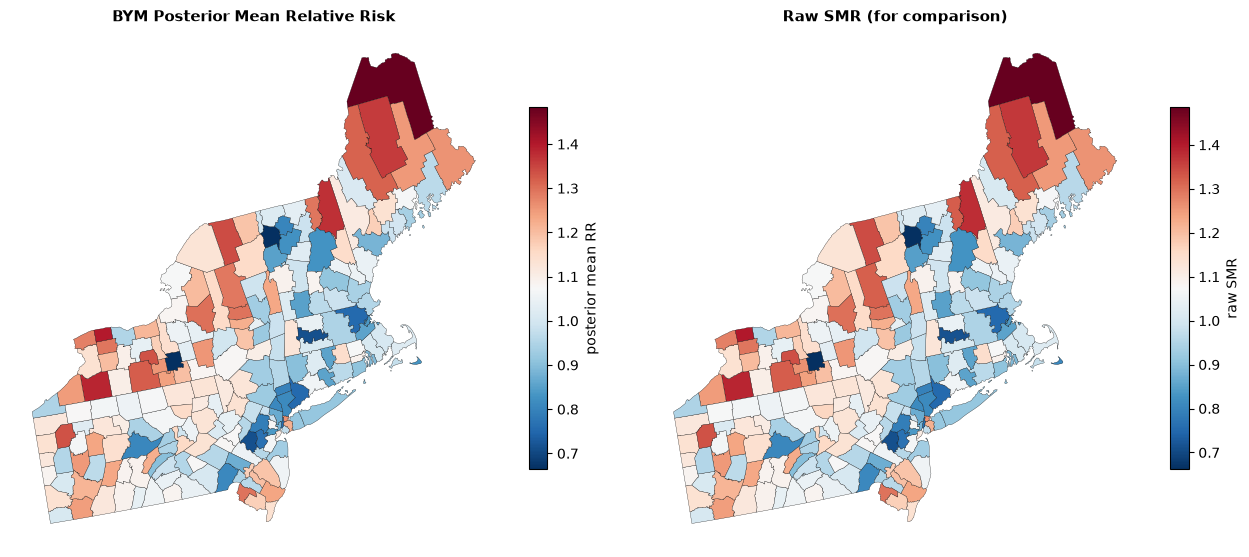

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
counties.assign(rr_mean=fit.rr_mean).plot(column="rr_mean", cmap="RdBu_r", ax=axes[0],
                                          edgecolor="k", linewidth=0.2, legend=True,
                                          legend_kwds={"label": "posterior mean RR", "shrink": 0.7})
axes[0].set_axis_off()
axes[0].set_title("BYM Posterior Mean Relative Risk")

counties.assign(smr=O / E).plot(column="smr", cmap="RdBu_r", ax=axes[1],
                                edgecolor="k", linewidth=0.2, legend=True,
                                legend_kwds={"label": "raw SMR", "shrink": 0.7})
axes[1].set_axis_off()
axes[1].set_title("Raw SMR (for comparison)")
plt.tight_layout()
plt.show()

***
## 5. Covariates: Residual Smoothing vs. Explanation

Adding a covariate changes *what the random effects are left to explain*. If obesity prevalence explains some
of the regional pattern in diabetes prevalence, the spatial fraction should drop once it enters the model —
what used to look like unexplained spatial structure becomes an explained covariate effect instead.

In [4]:
X = counties[["Obesity"]]
t0 = time.time()
fit_cov = BYM(O, E, w, X=X, model="bym", backend="gibbs", draws=2000, tune=2000, chains=4, thin=10, seed=1)
print(f"fit time: {time.time() - t0:.1f}s")
print(fit_cov.coef)
print(f"\nspatial fraction, no covariate  : {np.mean(fit.spatial_fraction):.3f}")
print(f"spatial fraction, with Obesity  : {np.mean(fit_cov.spatial_fraction):.3f}")

fit time: 12.4s
  variable     mean       sd       lo        hi
0  Obesity  0.02467  0.00196  0.02126  0.028788

spatial fraction, no covariate  : 0.473
spatial fraction, with Obesity  : 0.372


`Obesity`'s coefficient (0.0247, 95% CI comfortably away from 0) confirms a real, precisely estimated
association: on the log-risk scale, a one-point rise in county obesity prevalence associates with about a 2.5%
rise in diabetes relative risk, holding the random effects fixed. The spatial fraction drops from 0.47 to 0.37
— roughly a fifth of what looked like unexplained spatial structure is, once obesity is in the model, actually
explained by obesity's own (highly spatially patterned) distribution. This is the "residual smoothing vs.
explanation" distinction directly: without covariates, $u$ and $v$ must absorb *everything* left over after
the intercept; with covariates, they only need to absorb what the covariates cannot explain.

***
## 6. BYM2: A Cleaner Spatial-Fraction Parametrisation

BYM's raw $\tau_u$/$\tau_v$ parametrisation makes "spatial fraction" only computable *after* fitting, from the
realised draws of $u$ and $v$. **BYM2** (Riebler et al. 2016) reparametrises so a single parameter $\phi \in
[0,1]$ *is* the spatial fraction directly, by construction:

$$
b = \sigma\left(\sqrt{\phi/s}\; u^* + \sqrt{1-\phi}\; v^*\right),
$$

where $u^*$ is a *unit-scaled* ICAR field, $v^* \sim N(0,1)$, $\sigma$ is the total random-effect standard
deviation, and $s$ is the **Sørbye–Rue scaling factor** — the geometric mean of $u^*$'s own marginal variances
— which corrects for the fact that an ICAR field's marginal variance depends on the graph's structure, not just
its precision. Without $s$, $\phi$ would not mean "spatial fraction" consistently across different graphs.
BYM2 is available with `backend='pymc'` only.

In [5]:
island_idx = w.islands()[0]
island_id = w.id_order[island_idx]
wk1 = KNN(counties, k=1)
nearest_id = wk1.neighbors[island_id][0]
neighbors = {i: list(w.neighbors[i]) for i in w.id_order}
neighbors[island_id] = [nearest_id]
neighbors[nearest_id] = neighbors[nearest_id] + [island_id]
w_linked = W(neighbors, ids=w.id_order, transform="binary")   # PyMC needs a connected graph

t0 = time.time()
fit_bym2 = BYM(O, E, w_linked, model="bym2", backend="pymc", draws=1000, tune=1000, chains=4, seed=1,
              progressbar=False)
print(f"fit time: {time.time() - t0:.1f}s")
print(fit_bym2.summary())

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, sigma, phi, u_star, v_star]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


fit time: 41.8s
BYM2 model (pymc)
  areas 217   chains 4   draws/chain 1000
  DIC 2805.65   effective parameters 214.6
  spatial fraction of random-effect s.d.: 0.534
  max R-hat over relative risks 1.002   min ESS 3342

             mean      sd    q_lo    q_hi    rhat        ess
parameter                                                   
intercept  0.0401  0.0071  0.0262  0.0536  1.0006  2961.8968
sigma      0.1530  0.0111  0.1340  0.1768  1.0189   444.5923
phi        0.5339  0.1299  0.2867  0.7948  1.0169   298.4729


$\phi = 0.53$ — close to plain BYM's covariate-free spatial fraction of 0.47, DIC essentially tied (2805.7 vs.
2806.3), even though the two models reach that number via different mechanisms (BYM2's $\phi$ is a *prior
mixing weight* between two unit-scale fields, not a *post hoc* ratio of realised standard deviations the way
plain BYM's spatial fraction is). The two are not the same computation and are not guaranteed to agree
numerically, but here they tell a consistent story: roughly half the residual structure in diabetes prevalence
is spatial. **Worth flagging honestly:** PyMC's own diagnostics warn that `sigma` and `phi` have R-hat slightly
above 1.01 at only 1,000 post-warm-up draws per chain — a real, visible reminder (revisited formally in Chapter
5.7) that BYM2's posterior geometry can be harder to sample than plain BYM's, and a production analysis should
run longer before reporting these two parameters with full confidence.

***
## 7. What the Posterior Provides

Beyond the point summaries already used above, a full posterior supports queries a point estimate alone
cannot answer — most importantly, **exceedance probabilities**: the posterior probability that a county's true
relative risk exceeds some threshold, a direct, uncertainty-aware alternative to a hard significance cutoff.

In [6]:
exceed = fit.exceedance(1.0)
print(f"P(theta > 1) range: [{exceed.min():.3f}, {exceed.max():.3f}]")
print(f"counties with P(theta > 1) > 0.95 : {int((exceed > 0.95).sum())}")
print(f"counties with P(theta > 1) < 0.05 : {int((exceed < 0.05).sum())}")

fit.to_frame().assign(COUNTY=counties["COUNTY"]).sort_values("p_exceed_1", ascending=False).head(3)

P(theta > 1) range: [0.000, 1.000]
counties with P(theta > 1) > 0.95 : 125
counties with P(theta > 1) < 0.05 : 68


,observed,expected,smr,rr_mean,rr_median,rr_lo,rr_hi,p_exceed_1,COUNTY
1,67168.0,65727.222261,1.021921,1.021786,1.021767,1.014097,1.029644,1.0,Hartford County
7,9850.0,8587.489601,1.147017,1.145880,1.145756,1.123649,1.168363,1.0,Windham County
4,66825.0,63078.565857,1.059393,1.059203,1.059242,1.051216,1.067084,1.0,New Haven County


125 counties exceed a 95% posterior probability of elevated risk — far more than Part 4's Gi* found as formal
FDR-corrected "hot spots" (7 counties). This is not a contradiction: `exceedance` answers a **different**
question — "how confident are we this county's *own* risk exceeds the regional average" — without any
multiple-testing correction across the 217 counties, whereas Gi*/LISA explicitly correct for testing that many
hypotheses at once. An exceedance map is a screening tool for further investigation, not a substitute for a
formally corrected significance test; Chapter 5.8 returns to how smoothing changes what counts as a "cluster"
at all.

***
## 8. Summary and Conclusions

This chapter built the full BYM model, on real data, with a real covariate, and its BYM2 reparametrisation.

### What we did

1. Defined the BYM model: a spatially structured ICAR effect $u$ plus an unstructured effect $v$, combined on
   the log-risk scale.
2. Fit BYM on real diabetes counts: DIC 2806.3, spatial fraction 0.47.
3. Added `Obesity` as a covariate: a precisely estimated positive effect, and the spatial fraction dropping to
   0.37 — a fifth of the apparent spatial structure explained away by obesity's own spatial pattern.
4. Fit BYM2 via PyMC, getting $\phi=0.53$ as a directly interpretable spatial-fraction parameter — close to
   plain BYM's 0.47 — and flagged a real R-hat warning at only 1,000 draws/chain for this reparametrisation.
5. Computed exceedance probabilities and contrasted 125 "P(θ>1)>0.95" counties against Part 4's 7 FDR-corrected
   Gi* hot spots — different questions, not conflicting answers.

### Practical takeaways

- A dropping spatial fraction after adding a covariate is direct evidence the covariate is capturing part of
  what looked like unexplained geography — a useful, checkable diagnostic for covariate relevance.
- BYM2's $\phi$ and plain BYM's spatial fraction are both legitimate "how spatial is this" summaries but are
  computed differently; do not expect numerical agreement, only qualitative consistency.
- Exceedance probabilities are uncorrected per-area probabilities, not a substitute for Part 4's formally
  corrected cluster tests — use them for screening, not final significance claims.

### Next steps

**Chapter 5.7 (MCMC Implementation)** looks under the hood at how both backends actually produce these
posteriors, their diagnostics, and a real demonstration of what goes wrong when sampler settings are too
aggressive.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Besag, J., York, J. & Mollié, A. (1991). Bayesian image restoration, with two applications in spatial statistics. *Annals of the Institute of Statistical Mathematics*, 43, 1–20. | Origin of the BYM model |
| Riebler, A., Sørbye, S. H., Simpson, D. & Rue, H. (2016). An intuitive Bayesian spatial model for disease mapping that accounts for scaling. *Statistical Methods in Medical Research*, 25, 1145–1165. | Origin of BYM2 and the Sørbye–Rue scaling factor |

### Key papers

| Paper | Contribution |
|---|---|
| Sørbye, S. H. & Rue, H. (2014). Scaling intrinsic Gaussian Markov random field priors in spatial modelling. *Spatial Statistics*, 8, 39–51. | The scaling factor used by BYM2 |
| Richardson, S., Thomson, A., Best, N. & Elliott, P. (2004). Interpreting posterior relative risk estimates in disease-mapping studies. *Environmental Health Perspectives*, 112, 1016–1025. | Interpreting exceedance probabilities in disease mapping |

### In this library

| Object | Role |
|---|---|
| `spatialstats.bayes.BYM` | The full model, both `model='bym'`/`'bym2'` and both backends |
| `BYM.exceedance()` | Posterior exceedance probabilities |
| `BYM.spatial_fraction`, `.dic` | Model summaries used throughout this chapter |
| Chapter 5.7 | The MCMC machinery producing these posteriors |